In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

In [18]:
# Load the data
df = pd.read_csv('matches.csv')

In [20]:
df.head(4)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper


In [22]:
print(df.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [26]:
df.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [28]:
df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

# DATA CLEANING

# 1. Handling Missing Values (Filling missing city names with "Unknown")

In [32]:
df['city'].fillna('Unknown', inplace=True)


C:\Users\vishn\AppData\Local\Temp\ipykernel_6384\2814650169.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['city'].fillna('Unknown', inplace=True)


# 2. Converting Date Column to Date Format

In [35]:
df['date'] = pd.to_datetime(df['date'])


# 3. Removing Duplicate Rows

In [38]:
df.drop_duplicates(inplace=True)

# 4. Drop the "method" column (since it has 1074 missing values out of 1095 total rows)

In [41]:
df.drop(columns=['method'], inplace=True, errors='ignore')


df['result_margin'].fillna(0, inplace=True)
df['target_runs'].fillna(0, inplace=True)
df['target_overs'].fillna(0, inplace=True)

# 5. Fill missing values in numeric columns

In [45]:
df['result_margin'].fillna(0, inplace=True)
df['target_runs'].fillna(0, inplace=True)
df['target_overs'].fillna(0, inplace=True)
df['player_of_match'].fillna(0, inplace=True)
df['winner'].fillna(0, inplace=True)



C:\Users\vishn\AppData\Local\Temp\ipykernel_6384\3761095439.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['result_margin'].fillna(0, inplace=True)
C:\Users\vishn\AppData\Local\Temp\ipykernel_6384\3761095439.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

# 6. Verify if all missing values are handled

In [48]:
print(df.isnull().sum())  

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
umpire1            0
umpire2            0
dtype: int64


In [50]:
rcb_wins = df[df['winner'] == 'Royal Challengers Bangalore']
rcb_wins_per_season = rcb_wins['season'].value_counts().sort_index()


In [52]:
df[df['winner'] == 'Royal Challengers Bangalore']['player_of_match'].value_counts().head()


player_of_match
AB de Villiers    23
CH Gayle          17
V Kohli           15
JH Kallis          5
GJ Maxwell         4
Name: count, dtype: int64

In [54]:
matches_per_season = df['season'].value_counts().sort_index()
print("Matches Played Per Season:\n", matches_per_season)


Matches Played Per Season:
 season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


In [11]:
df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [50]:
df['season'].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [51]:
# Function to display top 10 values for any column
def display_top_10(column_name, title):
    top_10 = df[column_name].value_counts().head(10)
    print(f"--- Top 10 {title} ---")
    print(top_10.to_string())  # to_string() removes dtype info
    print("\n")

In [52]:
# 5. Top 10 Cities Hosting Matches
display_top_10('city', 'Cities Hosting Most Matches')


--- Top 10 Cities Hosting Most Matches ---
city
Mumbai        173
Kolkata        93
Delhi          90
Chennai        85
Hyderabad      77
Bangalore      65
Chandigarh     61
Jaipur         57
Pune           51
Unknown        51




In [53]:
# 1. Top 10 Teams with Most Wins
display_top_10('winner', 'Teams with Most Wins')


--- Top 10 Teams with Most Wins ---
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29




In [54]:
#  Top 10 Most Frequent Toss Decisions (Bat/Field)
if 'toss_decision' in df.columns:
    toss_decisions = df['toss_decision'].value_counts()
    print("--- Toss Decision Distribution ---")
    print(toss_decisions.to_string())
    print("\n")

--- Toss Decision Distribution ---
toss_decision
field    704
bat      391




# Who are the top 15 players with the highest number of "Player of the Match" awards?

C:\Users\vishn\AppData\Local\Temp\ipykernel_9024\3353933537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values, y=top_players.index, palette='rocket')


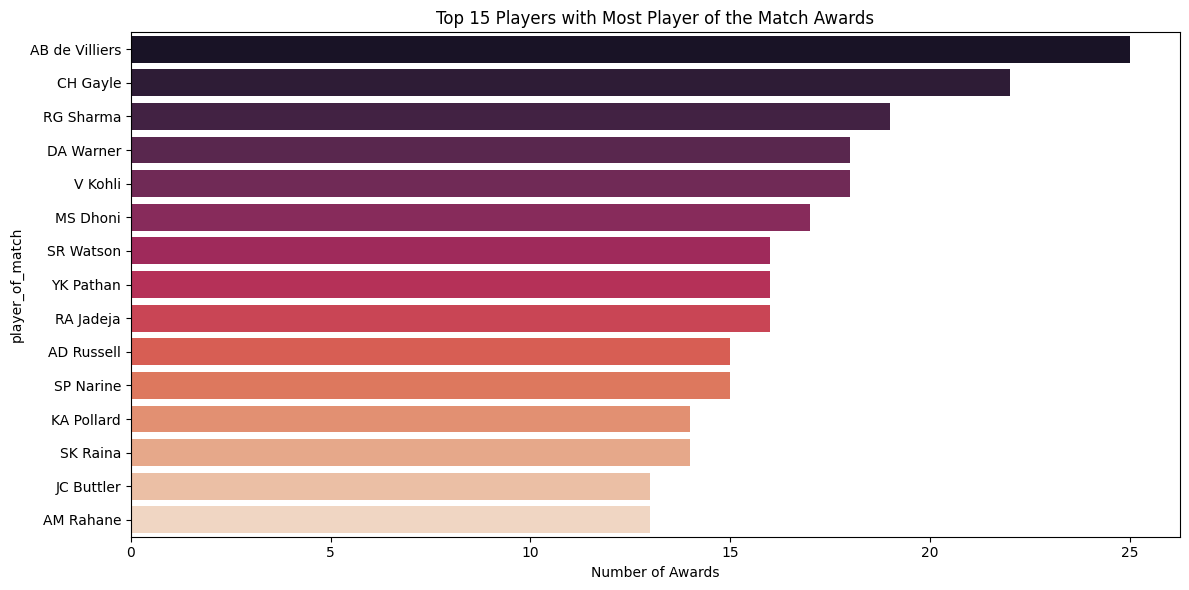

In [55]:
plt.figure(figsize=(12, 6))
top_players = df['player_of_match'].value_counts().head(15)
sns.barplot(x=top_players.values, y=top_players.index, palette='rocket')
plt.title('Top 15 Players with Most Player of the Match Awards')
plt.xlabel('Number of Awards')
plt.tight_layout()
plt.show()

# Which teams have won the most matches?

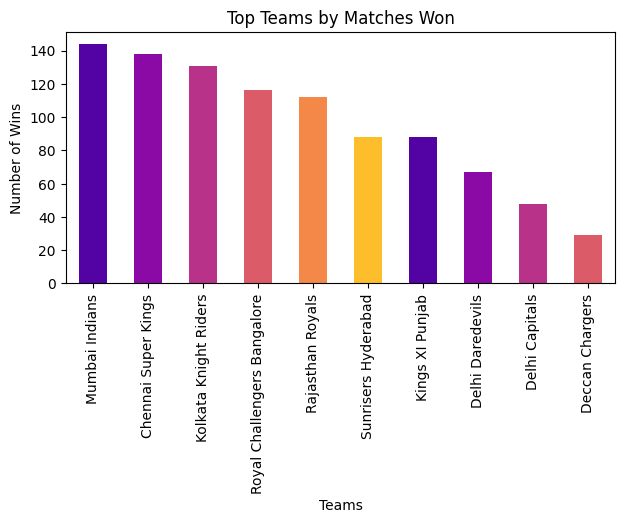

In [56]:
plt.figure(figsize=(12, 8))  
plt.subplot(2, 2, 2)
top_teams = df['winner'].value_counts().head(10)
top_teams.plot(kind='bar', color=sns.color_palette('plasma'))
plt.title('Top Teams by Matches Won')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')

plt.tight_layout()
plt.show()

# What is the percentage distribution of toss decisions?

Text(0, 0.5, '')

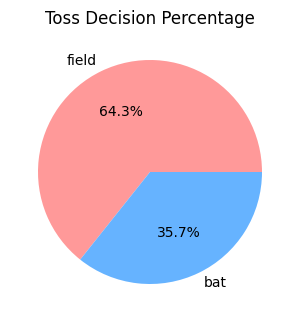

In [58]:
plt.figure(figsize=(10, 8))
plt.subplot(2,2,3)
toss_decision = df['toss_decision'].value_counts()
toss_decision.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Toss Decision Percentage')
plt.ylabel('')

# How do teams win matches—by runs or by wickets?

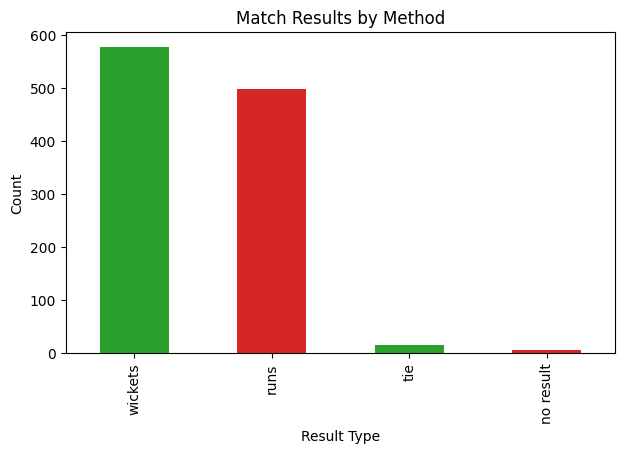

In [59]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 4)
win_method = df['result'].value_counts()
win_method.plot(kind='bar', color=['#2ca02c', '#d62728'])
plt.title('Match Results by Method')
plt.xlabel('Result Type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# How are team wins distributed in the dataset?

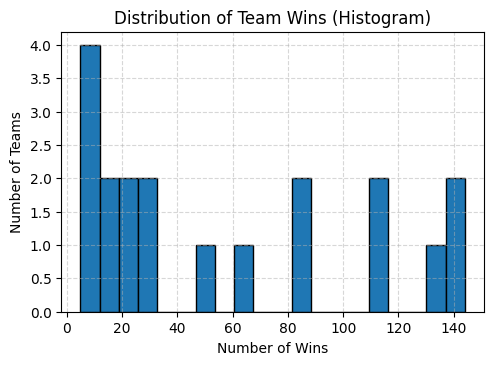

In [63]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 2)
win_counts = df['winner'].value_counts()
plt.hist(win_counts, bins=20, color='#1f77b4', edgecolor='black')
plt.title('Distribution of Team Wins (Histogram)')
plt.xlabel('Number of Wins')
plt.ylabel('Number of Teams')
plt.grid(True, linestyle='--', alpha=0.5)

# How many matches were played in each season

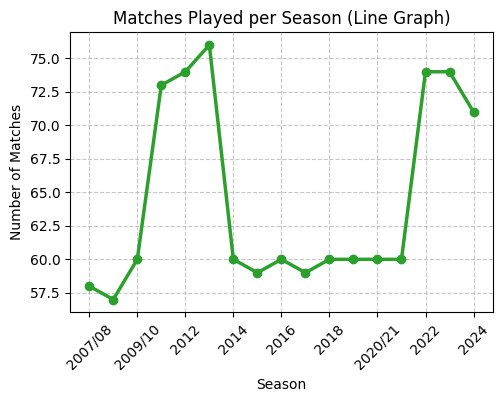

In [65]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
matches_per_season = df['season'].value_counts().sort_index()
matches_per_season.plot(kind='line', marker='o', color='#2ca02c', linewidth=2.5)
plt.title('Matches Played per Season (Line Graph)')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

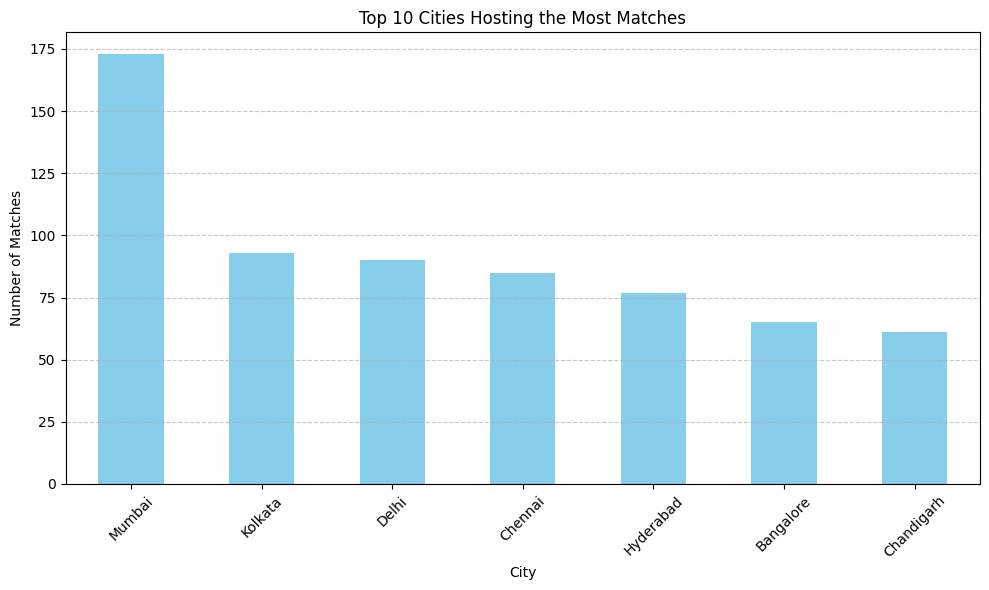

In [68]:
city_match_counts = df['city'].value_counts().nlargest(7)
plt.figure(figsize=(10, 6))
city_match_counts.plot(kind='bar', color='skyblue')
plt.title('Top 10 Cities Hosting the Most Matches')
plt.xlabel('City')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

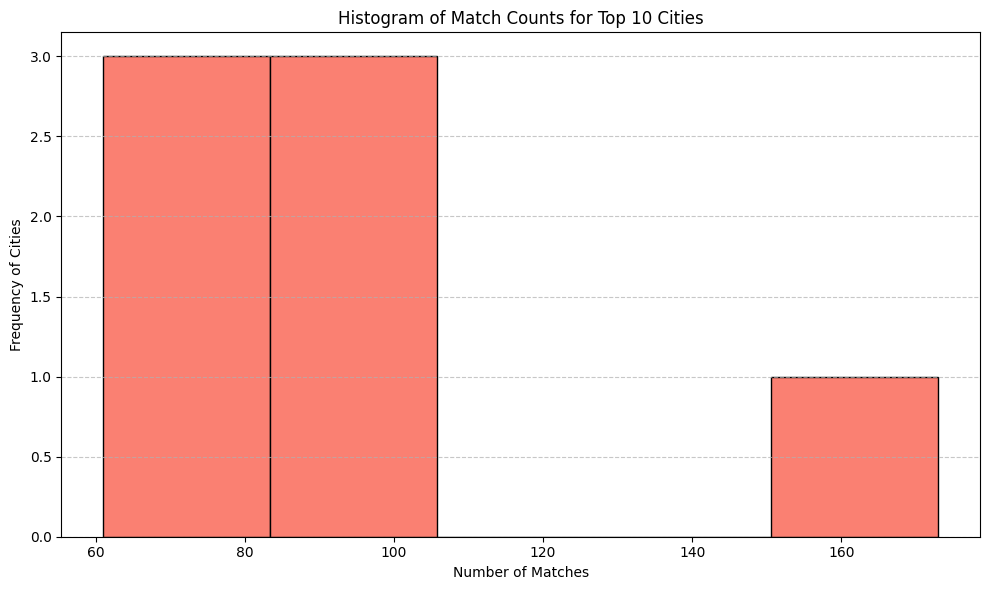

In [69]:
city_match_counts = df['city'].value_counts()

# Take only the top 10 cities
top_10_city_counts = city_match_counts.nlargest(7)

# Plot histogram of match counts
plt.figure(figsize=(10, 6))
plt.hist(top_10_city_counts.values, bins=5, color='salmon', edgecolor='black')
plt.title('Histogram of Match Counts for Top 10 Cities')
plt.xlabel('Number of Matches')
plt.ylabel('Frequency of Cities')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()